In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Настройка стилей
sns.set(style="whitegrid")
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Загрузка данных
data_path = os.path.join('installed_software.csv')
df = pd.read_csv(data_path)

print(f"Форма данных: {df.shape}")
print(f"Колонки: {list(df.columns)}")
df.head()

Форма данных: (395, 4)
Колонки: ['DisplayName', 'DisplayVersion', 'Publisher', 'InstallDate']


,DisplayName,DisplayVersion,Publisher,InstallDate
0,µTorrent,3.5.5.45790,BitTorrent Inc.,NaN
1,1527c705-839a-4832-9118-54d4Bd6a0c89,10.0.19640.1000,"CN=Microsoft Windows, O=Microsoft Corporation,...",NaN
2,28466Polysoft.SimpleContacts,2.3.5.0,CN=44AF4FB5-F779-4E31-8548-13B1615E98FA,NaN
3,3D4Medical.comLLC.CompleteAnatomy,12.2.2.0,CN=9963410B-B57E-49F4-9A17-94C70C3F5932,NaN
4,5319275A.WhatsAppDesktop,2.2616.100.0,CN=24803D75-212C-471A-BC57-9EF86AB91435,NaN


In [4]:
# Базовая информация
print(f"Всего записей: {len(df)}")
print(f"Уникальных вендоров: {df['Publisher'].nunique()}")
df.describe(include='all')

Всего записей: 395
Уникальных вендоров: 68


,DisplayName,DisplayVersion,Publisher,InstallDate
count,395,393,393,171
unique,345,275,68,52
top,Microsoft.WindowsAppRuntime.1.8,14.0.1000.169,"CN=Microsoft Corporation, O=Microsoft Corporat...",20191207
freq,6,20,137,36


C:\Users\MI\AppData\Local\Temp\ipykernel_6056\4030046582.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vendor_counts.values, y=vendor_counts.index, palette='coolwarm')


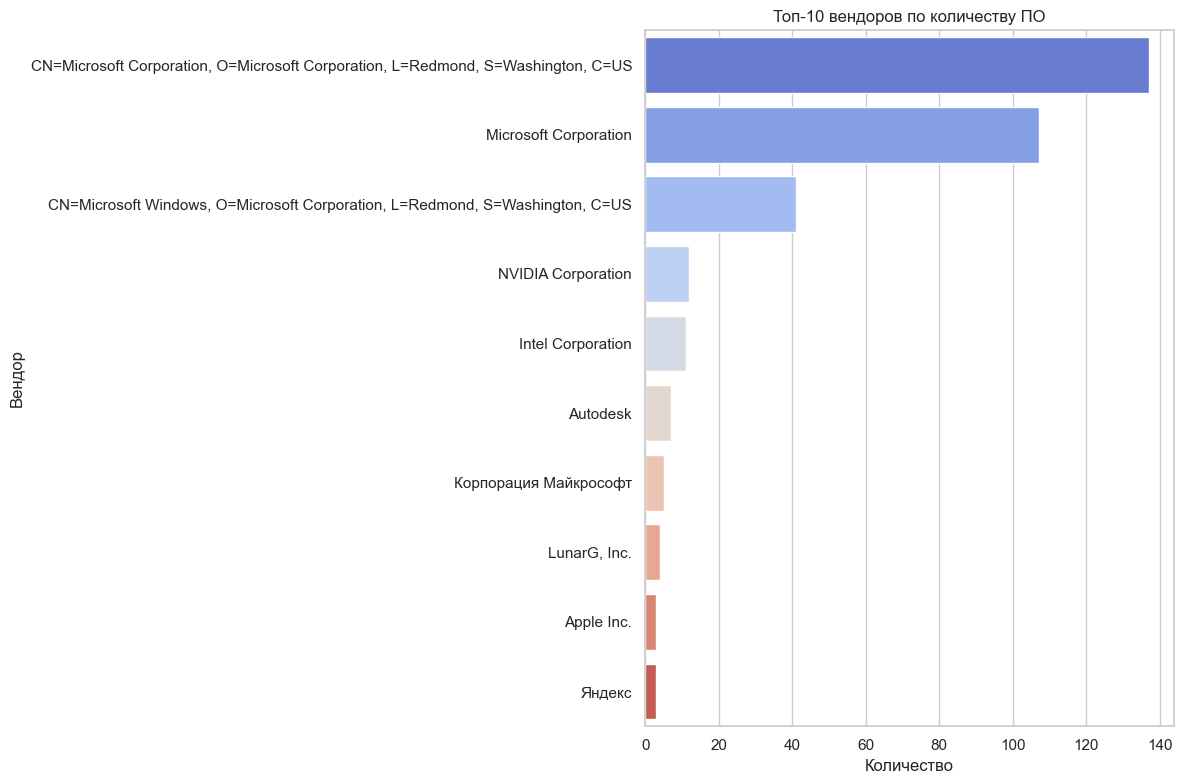

In [5]:
# Топ вендоров
plt.figure(figsize=(12, 8))
vendor_counts = df['Publisher'].value_counts().head(10)
sns.barplot(x=vendor_counts.values, y=vendor_counts.index, palette='coolwarm')
plt.title('Топ-10 вендоров по количеству ПО')
plt.xlabel('Количество')
plt.ylabel('Вендор')
plt.tight_layout()
plt.show()

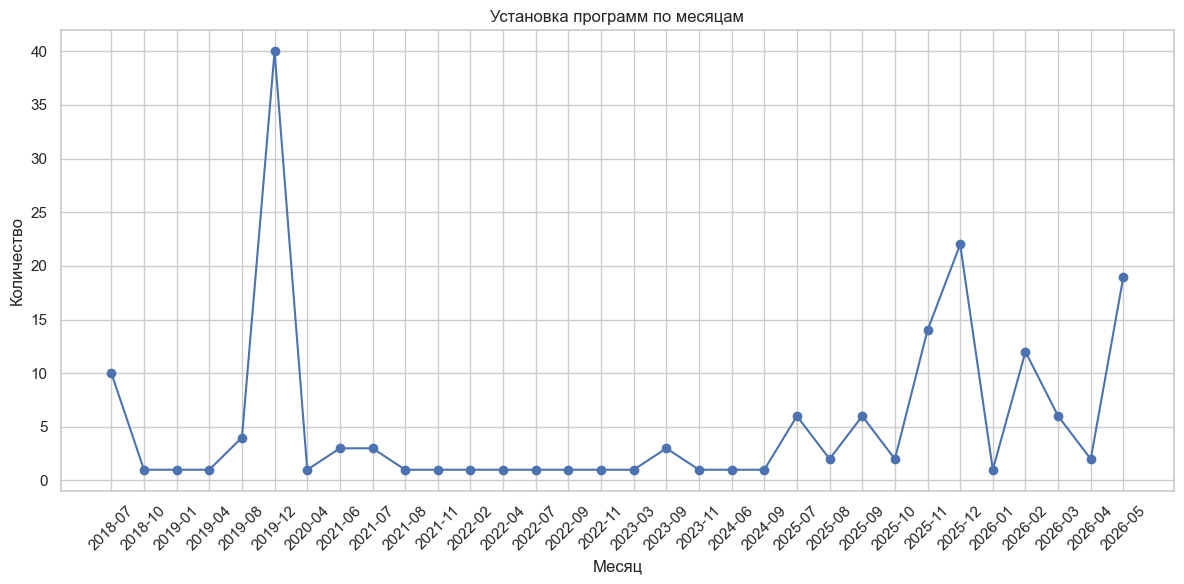

In [6]:
# Временная шкала (если есть InstallDate)
if 'InstallDate' in df.columns:
    dates = pd.to_datetime(df['InstallDate'], errors='coerce')
    dates = dates.dropna()
    
    monthly = dates.dt.to_period('M').value_counts().sort_index()
    
    plt.figure(figsize=(12, 6))
    plt.plot(monthly.index.astype(str), monthly.values, marker='o')
    plt.title('Установка программ по месяцам')
    plt.xlabel('Месяц')
    plt.ylabel('Количество')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Колонка InstallDate не найдена")